# Statistisk evaluering: Haiku vs Opus på eksamensopgaver
**Kursus 02445** — samlet analyse-notebook, struktureret efter rapporten.

## Datasættets konstruktion og den statistiske enhed
54 distinkte MC-spørgsmål (2 eksamenssæt à 27), hvert besvaret **5 gange** pr. model.
**Enheden er spørgsmålet (n = 54)** — de 5 gentagelser er ikke uafhængige, så de
behandles som præcisionsforbedring pr. spørgsmål, ikke som ekstra observationer.

## Kobling til rapportens struktur
- **Afsnit 3 (Statistical methods):** pilot → Connor power-analyse (McNemar-baseret) → Jeffreys → McNemar → χ²/permutation pr. kategori
- **Afsnit 4 (Results):** accuracytabel m. Jeffreys-CI'er, søjlediagram m. fejlbjælker, McNemar-kontingenstabel + θ-fordeling, accuracy pr. kategori, χ²-resultater, selv-konsistens-boxplot
- Wilcoxon beholdes som supplerende test (bruger al information fra de 5 gentagelser)

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

alpha = 0.05
REPS  = 5

## 1. Indlæs og rens data

In [2]:
DATA_PATH = "Dataset.csv"

df = pd.read_csv(DATA_PATH, sep=";", encoding="utf-8-sig")
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
df.columns = df.columns.str.strip()
df = df.rename(columns={"Haiko True": "Haiku True",
                        "Haiko False": "Haiku False"})
df["Q_Type"] = df["Q_Type"].str.strip().replace({"Knowlegde": "Knowledge"})
df

,Examset,Question,Q_Type,Haiku True,Haiku False,Opus True,Opus False
0,Spring 2025,1,Visual,5,0,5,0
1,Spring 2025,2,Visual,0,5,5,0
2,Spring 2025,3,Computational,0,5,5,0
3,Spring 2025,4,Visual,4,1,4,1
4,Spring 2025,5,Knowledge,0,5,5,0
5,Spring 2025,6,Computational,1,4,5,0
6,Spring 2025,7,Computational,0,5,5,0
7,Spring 2025,8,Computational,0,5,5,0
8,Spring 2025,9,Visual,0,5,5,0
9,Spring 2025,10,Computational,0,5,1,4


## 2. Sanity checks

In [3]:
assert len(df) == 54, f"Forventede 54 spørgsmål, fik {len(df)}"
ok_h = (df["Haiku True"] + df["Haiku False"] == REPS).all()
ok_o = (df["Opus True"]  + df["Opus False"]  == REPS).all()
print("54 spørgsmål:", len(df) == 54)
print("5 gentagelser pr. spørgsmål (Haiku/Opus):", bool(ok_h), bool(ok_o))
print("\nSpørgsmål pr. type:\n", df["Q_Type"].value_counts().to_string())
print("\nSpørgsmål pr. eksamenssæt:\n", df["Examset"].value_counts().to_string())

54 spørgsmål: True
5 gentagelser pr. spørgsmål (Haiku/Opus): True True

Spørgsmål pr. type:
 Q_Type
Visual           27
Computational    17
Knowledge        10

Spørgsmål pr. eksamenssæt:
 Examset
Spring 2025    27
Fall 2025      27


## 3. Deskriptiv accuracy (middel pr. spørgsmål, pr. type)
Middel-accuracy (andel af 5, midlet over spørgsmål) bruges i det *kontinuerte* spor (Wilcoxon).
Rapportens hovedtal er majority-vote-accuracy (afsnit 6–7 nedenfor). Rent beskrivende.

MEAN ACCURACY BY QUESTION TYPE (deskriptivt)

Overall:  Haiku 44.1%   Opus 85.6%   Diff +41.5%

Computational:  Haiku 22.4%   Opus 95.3%   Diff +72.9%

Knowledge:  Haiku 60.0%   Opus 92.0%   Diff +32.0%

Visual:  Haiku 51.9%   Opus 77.0%   Diff +25.2%


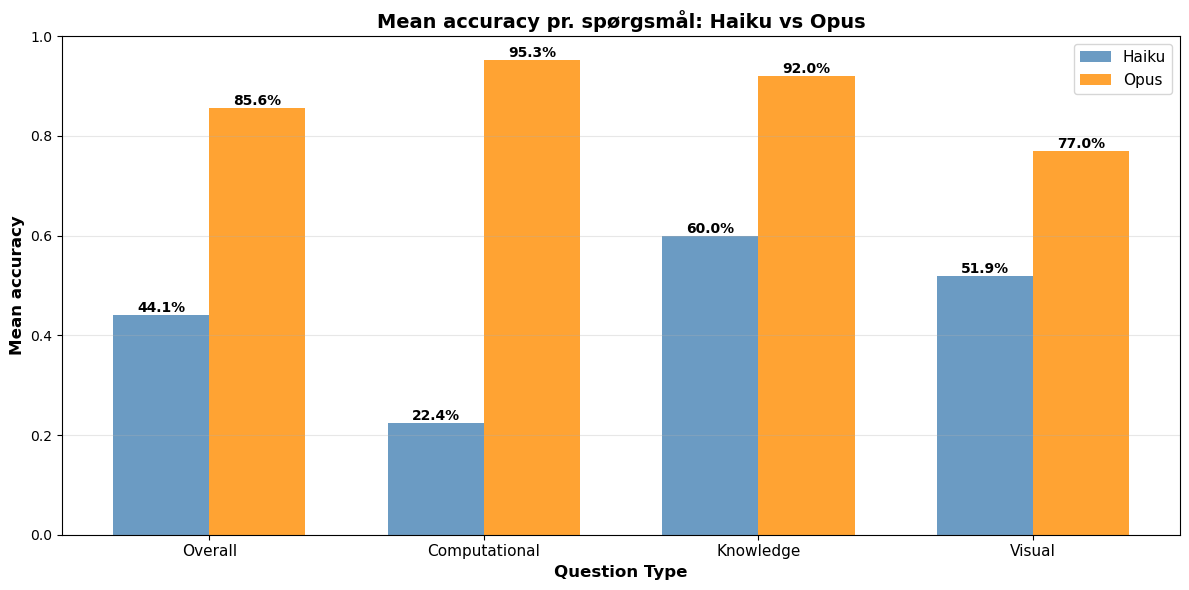

In [4]:
df["Haiku_acc"] = df["Haiku True"] / REPS
df["Opus_acc"]  = df["Opus True"]  / REPS

results = {"Overall": [df["Haiku_acc"].mean(), df["Opus_acc"].mean()]}
for qtype in sorted(df["Q_Type"].unique()):
    sub = df[df["Q_Type"] == qtype]
    results[qtype] = [sub["Haiku_acc"].mean(), sub["Opus_acc"].mean()]

print("=" * 60); print("MEAN ACCURACY BY QUESTION TYPE (deskriptivt)"); print("=" * 60)
for qtype, accs in results.items():
    print(f"\n{qtype}:  Haiku {accs[0]:.1%}   Opus {accs[1]:.1%}   Diff {accs[1]-accs[0]:+.1%}")

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results)); width = 0.35
h_vals = [results[k][0] for k in results]; o_vals = [results[k][1] for k in results]
b1 = ax.bar(x - width/2, h_vals, width, label="Haiku", color="steelblue", alpha=0.8)
b2 = ax.bar(x + width/2, o_vals, width, label="Opus",  color="darkorange", alpha=0.8)
ax.set_ylabel("Mean accuracy", fontsize=12, fontweight="bold")
ax.set_xlabel("Question Type", fontsize=12, fontweight="bold")
ax.set_title("Mean accuracy pr. spørgsmål: Haiku vs Opus", fontsize=14, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(results.keys(), fontsize=11)
ax.legend(fontsize=11); ax.set_ylim([0, 1]); ax.grid(True, alpha=0.3, axis="y")
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                f"{bar.get_height():.1%}", ha="center", va="bottom",
                fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

## 4. Pilotstudie
Pilotens accuracies beregnes fra `final pilot.csv` (27 spørgsmål).

In [5]:
pilot_path = "final pilot.csv"
df_pilot_study = pd.read_csv(pilot_path, sep=";", encoding="utf-8-sig", skiprows=2)
df_pilot_study.columns = ['ID', 'Semester', 'Question', 'Haiku_True', 'Haiku_False', 'Opus_True', 'Opus_False']
df_pilot_study = df_pilot_study.fillna(0)
df_pilot_study

,ID,Semester,Question,Haiku_True,Haiku_False,Opus_True,Opus_False
0,2,Fall 2025,B,0.0,1.0,1.0,0.0
1,3,Fall 2025,A,1.0,0.0,1.0,0.0
2,4,Fall 2025,D,1.0,0.0,1.0,0.0
3,5,Fall 2025,C,1.0,0.0,1.0,0.0
4,6,Fall 2025,B,0.0,1.0,0.0,1.0
5,7,Fall 2025,A,1.0,0.0,1.0,0.0
6,8,Fall 2025,C,1.0,0.0,1.0,0.0
7,9,Fall 2025,B,1.0,0.0,1.0,0.0
8,10,Fall 2025,D,1.0,0.0,0.0,1.0
9,11,Fall 2025,A,0.0,1.0,1.0,0.0


In [6]:
haiku_correct = df_pilot_study['Haiku_True'].sum()
opus_correct = df_pilot_study['Opus_True'].sum()

accuracy_haiku = haiku_correct / 27
accuracy_opus = opus_correct / 27

print(f"Haiku: {int(haiku_correct)}/27 = {accuracy_haiku:.1%}")
print(f"Opus:  {int(opus_correct)}/27 = {accuracy_opus:.1%}")

Haiku: 16/27 = 59.3%
Opus:  23/27 = 85.2%


### 4a. Uparret to-proportions-formel (til sammenligning)
Denne formel antager to *uafhængige* grupper og overvurderer derfor kravet til n i et parret design.
Vist som kontrast til den parrede Connor-beregning nedenfor.

In [23]:
# Discordant pairs from the pilot study
b = 0   # only Haiku correct
c = 8   # only Opus correct
n_pilot = 27

alfa = 0.01
power = 0.90
z_alfa_2 = st.norm.ppf(1 - alfa/2)   # 1.960
z_beta   = st.norm.ppf(power)        # 0.842

p_disc = (b + c) / n_pilot           # proportion of discordant pairs
delta  = (c - b) / n_pilot           # accuracy difference to detect

n = (z_alfa_2 * np.sqrt(p_disc) + z_beta * np.sqrt(p_disc - delta**2))**2 / delta**2
n = np.ceil(n)
print(n)

45.0


### 4b. Connor power-analyse (McNemar-baseret, matcher det parrede design)
Connor (1987): krævet antal par for McNemar ved signifikansniveau $\alpha$ og styrke $1-\beta$:

$$n = \frac{\left[z_{1-\alpha/2}\sqrt{\psi} + z_{1-\beta}\sqrt{\psi - \delta^2}\,\right]^2}{\delta^2}$$

hvor $\psi = p_{12}+p_{21}$ er andelen af *uenige* par og $\delta = |p_{12}-p_{21}|$ er effekten.
$\psi$ og $\delta$ estimeres fra pilotens majority-votede udfald. Power-tabellen viser
hvor mange spørgsmål forskellige effektstørrelser ville kræve.

In [8]:
# Majority vote pr. pilot-spørgsmål -> uenige andele
ph = (df_pilot_study['Haiku_True'] > df_pilot_study['Haiku_False']).astype(int)
po = (df_pilot_study['Opus_True']  > df_pilot_study['Opus_False']).astype(int)
p12 = ((ph == 0) & (po == 1)).mean()   # kun Opus rigtig
p21 = ((ph == 1) & (po == 0)).mean()   # kun Haiku rigtig
psi, delta = p12 + p21, abs(p12 - p21)
print(f"Pilot: p12 (kun Opus) = {p12:.3f}   p21 (kun Haiku) = {p21:.3f}")
print(f"       psi (uenige)   = {psi:.3f}   delta (effekt)  = {delta:.3f}")

def connor_n(psi, delta, alpha=0.05, power=0.80):
    if delta <= 0 or psi <= delta**2:
        return np.inf
    za, zb = st.norm.ppf(1 - alpha/2), st.norm.ppf(power)
    return (za*np.sqrt(psi) + zb*np.sqrt(psi - delta**2))**2 / delta**2

n_pilot = connor_n(psi, delta)
print(f"\nConnor n ud fra pilotens estimater (power 0.80): "
      f"{'uendelig (delta=0)' if np.isinf(n_pilot) else f'{n_pilot:.0f} spørgsmål'}")

# Power-tabel: krævet n for forskellige effektstørrelser (psi fastholdt på pilotens)
rows = []
for d in [0.10, 0.20, 0.30, 0.40, 0.50]:
    if d**2 < psi:
        rows.append({"delta": d,
                     "n (power 0.80)": round(connor_n(psi, d, power=0.80)),
                     "n (power 0.90)": round(connor_n(psi, d, power=0.90))})
power_table = pd.DataFrame(rows)
print("\nPower-tabel (Connor, alpha = 0.05, psi fra pilot):")
print(power_table.to_string(index=False))

Pilot: p12 (kun Opus) = 0.308   p21 (kun Haiku) = 0.038
       psi (uenige)   = 0.346   delta (effekt)  = 0.269

Connor n ud fra pilotens estimater (power 0.80): 35 spørgsmål

Power-tabel (Connor, alpha = 0.05, psi fra pilot):
 delta  n (power 0.80)  n (power 0.90)
   0.1             269             360
   0.2              66              87
   0.3              28              36
   0.4              14              18
   0.5               8              10


## 5. Binarisering: flertalsafstemning (≥3/5)
Rapportens primære accuracy-definition: et spørgsmål er "løst" hvis modellen
svarer korrekt i flertallet af de 5 gentagelser. 5 er ulige, så uafgjort er umuligt.

In [9]:
df["Haiku_bin"] = (df["Haiku True"] > df["Haiku False"]).astype(int)
df["Opus_bin"]  = (df["Opus True"]  > df["Opus False"]).astype(int)
n = len(df)
print(f"Haiku løste {df['Haiku_bin'].sum()}/{n} spørgsmål")
print(f"Opus  løste {df['Opus_bin'].sum()}/{n} spørgsmål")

Haiku løste 23/54 spørgsmål
Opus  løste 46/54 spørgsmål


## 6. Accuracy pr. model med Jeffreys 95%-CI (n = 54)

JEFFREYS INTERVAL (95% CI)  —  n = 54

Haiku:  theta = 0.427   CI = [0.301, 0.559]
Opus:   theta = 0.845   CI = [0.740, 0.927]


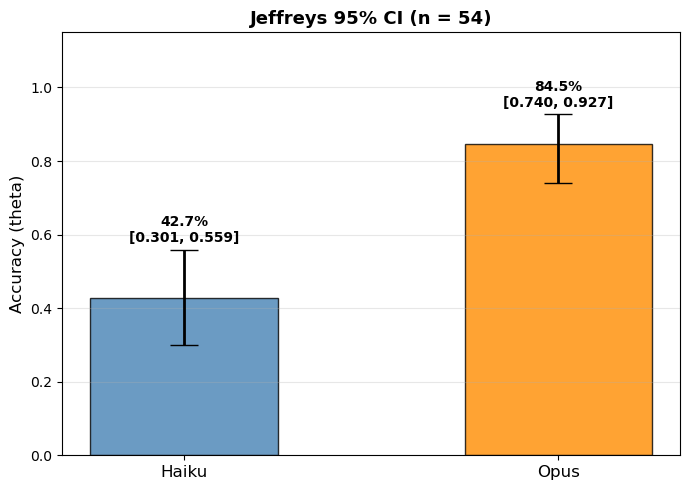

In [10]:
def jeffrey_interval(m, n, alpha=0.05):
    a, b = m + 0.5, n - m + 0.5
    return a / (a + b), st.beta.interval(1 - alpha, a, b)

m_h, m_o = df["Haiku_bin"].sum(), df["Opus_bin"].sum()
th_h, ci_h = jeffrey_interval(m_h, n)
th_o, ci_o = jeffrey_interval(m_o, n)
print("=" * 60); print("JEFFREYS INTERVAL (95% CI)  —  n = 54"); print("=" * 60)
print(f"\nHaiku:  theta = {th_h:.3f}   CI = [{ci_h[0]:.3f}, {ci_h[1]:.3f}]")
print(f"Opus:   theta = {th_o:.3f}   CI = [{ci_o[0]:.3f}, {ci_o[1]:.3f}]")

fig, ax = plt.subplots(figsize=(7, 5))
for i, (mdl, th, ci, c) in enumerate(zip(["Haiku","Opus"], [th_h,th_o],
                                         [ci_h,ci_o], ["steelblue","darkorange"])):
    ax.bar(i, th, color=c, alpha=0.8, edgecolor="black", width=0.5)
    ax.errorbar(i, th, yerr=[[th-ci[0]],[ci[1]-th]], fmt="none",
                color="black", capsize=10, linewidth=2)
    ax.text(i, ci[1]+0.02, f"{th:.1%}\n[{ci[0]:.3f}, {ci[1]:.3f}]",
            ha="center", fontsize=10, fontweight="bold")
ax.set_xticks([0,1]); ax.set_xticklabels(["Haiku","Opus"], fontsize=12)
ax.set_ylim([0,1.15]); ax.set_ylabel("Accuracy (theta)", fontsize=12)
ax.set_title("Jeffreys 95% CI (n = 54)", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

### 6b. Majority-vote accuracy pr. kategori med Jeffreys-fejlbjælker
Søjlediagram med fejlbjælker til Results. Bemærk de brede intervaller — subgrupperne
(10–27 spørgsmål) er deskriptive, ikke powered til selvstændige tests.

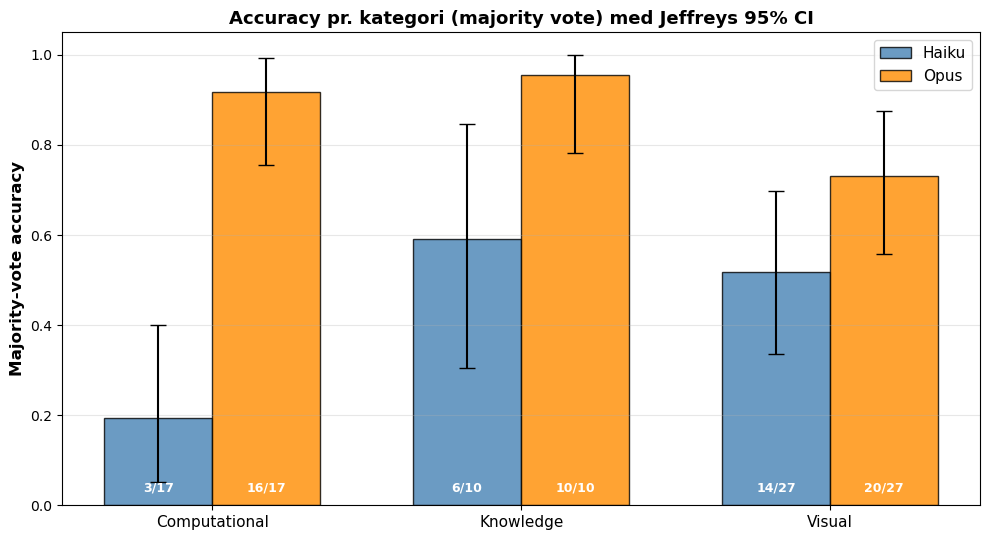

In [11]:
cats = sorted(df["Q_Type"].unique())
fig, ax = plt.subplots(figsize=(10, 5.5))
width = 0.35; x = np.arange(len(cats))
for j, (col, navn, c) in enumerate([("Haiku_bin","Haiku","steelblue"),
                                    ("Opus_bin","Opus","darkorange")]):
    ths, lo, hi, labels = [], [], [], []
    for qt in cats:
        sub = df[df["Q_Type"] == qt]; m = int(sub[col].sum()); nq = len(sub)
        th, ci = jeffrey_interval(m, nq)
        ths.append(th); lo.append(th-ci[0]); hi.append(ci[1]-th); labels.append(f"{m}/{nq}")
    pos = x + (j - 0.5) * width
    ax.bar(pos, ths, width, color=c, alpha=0.8, edgecolor="black", label=navn)
    ax.errorbar(pos, ths, yerr=[lo, hi], fmt="none", color="black", capsize=6, linewidth=1.5)
    for p_, t_, l_ in zip(pos, ths, labels):
        ax.text(p_, 0.03, l_, ha="center", fontsize=9, fontweight="bold", color="white")
ax.set_xticks(x); ax.set_xticklabels(cats, fontsize=11)
ax.set_ylabel("Majority-vote accuracy", fontsize=12, fontweight="bold")
ax.set_title("Accuracy pr. kategori (majority vote) med Jeffreys 95% CI", fontsize=13, fontweight="bold")
ax.set_ylim([0, 1.05]); ax.legend(fontsize=11); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## 7. McNemar's test (parret, n = 54) + kontingenstabel
Primær test for $H_0\!: p_H = p_O$. $\theta$ = accuracy(Opus) − accuracy(Haiku).

McNEMAR TEST  —  n = 54

  Begge rigtige:        21
  Kun Opus rigtig:      25
  Kun Haiku rigtig:     2
  Begge forkerte:       6
  Uenige par (n12+n21): 27

  theta (Opus - Haiku): +0.426
  95% CI:               [0.271, 0.569]
  p-værdi:              5.65e-06

  SIGNIFIKANT  Opus bedre end Haiku


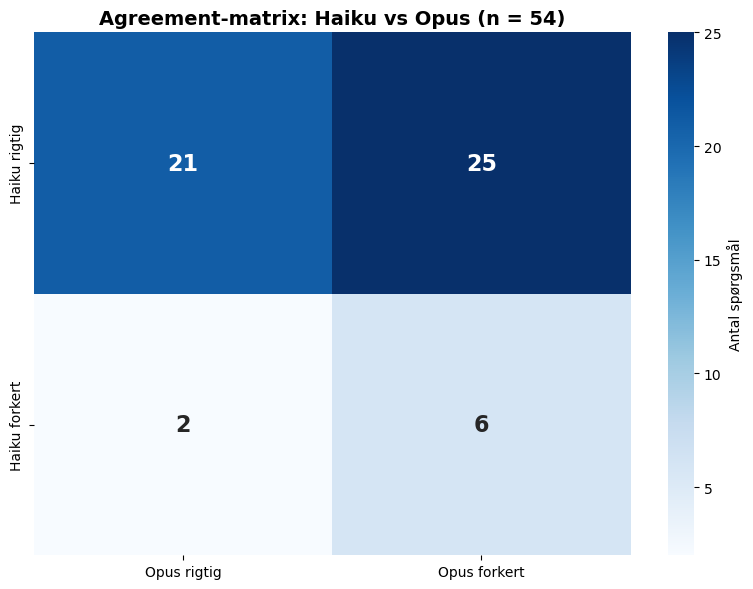

In [12]:
def mcnemar(yA, yB, alpha=0.05):
    """theta = acc(A) - acc(B). Kald med A=Opus, B=Haiku."""
    cA, cB = yA == 1, yB == 1
    n11 = int((cA &  cB).sum())
    n12 = int((cA & ~cB).sum())   # kun A (Opus) rigtig
    n21 = int((~cA & cB).sum())   # kun B (Haiku) rigtig
    n22 = int((~cA & ~cB).sum())
    N = len(yA); E = (n12 - n21) / N
    Q = (N**2 * (N+1) * (E+1) * (1-E)) / (N*(n12+n21) - (n12-n21)**2)
    f = (E+1)/2 * (Q-1); g = (1-E)/2 * (Q-1)
    CI = tuple(b*2 - 1 for b in st.beta.interval(1-alpha, a=f, b=g))
    p  = 2 * st.binom.cdf(min(n12, n21), n=n12+n21, p=0.5)
    return E, CI, p, (n11, n12, n21, n22)

E, CI_mc, p_mc, (n11, n12, n21, n22) = mcnemar(df["Opus_bin"].values, df["Haiku_bin"].values)
print("=" * 60); print("McNEMAR TEST  —  n = 54"); print("=" * 60)
print(f"\n  Begge rigtige:        {n11}")
print(f"  Kun Opus rigtig:      {n12}")
print(f"  Kun Haiku rigtig:     {n21}")
print(f"  Begge forkerte:       {n22}")
print(f"  Uenige par (n12+n21): {n12 + n21}")
print(f"\n  theta (Opus - Haiku): {E:+.3f}")
print(f"  95% CI:               [{CI_mc[0]:.3f}, {CI_mc[1]:.3f}]")
print(f"  p-værdi:              {p_mc:.2e}")
print("\n  SIGNIFIKANT  Opus bedre end Haiku" if p_mc < alpha
      else f"\n  IKKE signifikant (p >= {alpha})")
print("=" * 60)

matrix = np.array([[n11, n12], [n21, n22]])
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Opus rigtig","Opus forkert"],
            yticklabels=["Haiku rigtig","Haiku forkert"],
            cbar_kws={"label":"Antal spørgsmål"}, annot_kws={"size":16,"weight":"bold"})
ax.set_title("Agreement-matrix: Haiku vs Opus (n = 54)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

### 7b. McNemar: fordeling af θ

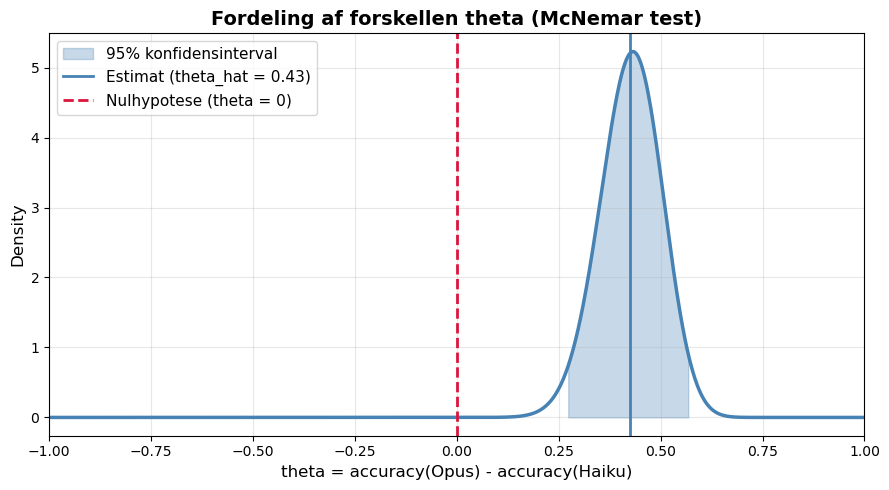

In [13]:
N = len(df)
E_plot = (n12 - n21) / N
Q_plot = N**2 * (N + 1) * (E_plot + 1) * (1 - E_plot) / (N * (n12 + n21) - (n12 - n21)**2)
f_plot = (E_plot + 1) / 2 * (Q_plot - 1)
g_plot = (1 - E_plot) / 2 * (Q_plot - 1)

theta = np.linspace(-1, 1, 1000)
density = 0.5 * st.beta.pdf((theta + 1) / 2, a=f_plot, b=g_plot)

plt.figure(figsize=(9, 5))
plt.plot(theta, density, color="steelblue", linewidth=2.5)
inside = (theta >= CI_mc[0]) & (theta <= CI_mc[1])
plt.fill_between(theta[inside], density[inside], color="steelblue", alpha=0.3,
                 label="95% konfidensinterval")
plt.axvline(E, color="steelblue", linewidth=2, label=f"Estimat (theta_hat = {E:.2f})")
plt.axvline(0, color="crimson", linestyle="--", linewidth=2, label="Nulhypotese (theta = 0)")
plt.xlabel("theta = accuracy(Opus) - accuracy(Haiku)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Fordeling af forskellen theta (McNemar test)", fontsize=14, fontweight="bold")
plt.legend(fontsize=11); plt.grid(alpha=0.3); plt.margins(x=0)
plt.tight_layout(); plt.show()

## 8. Afhænger udfaldet af spørgsmålstype? (within-model, n = 54)
Gyldig kategorianalyse: uafhængighedstest mellem Q_Type og løst/ikke-løst **inden for én
model ad gangen** — enheden er de 54 uafhængige spørgsmål. Svarer på forskningsspørgsmål (c).
Asymptotisk $\chi^2$ kræver forventede celletal ≥ 5; hvor det brydes (Opus), rapporteres i
stedet en permutations-p-værdi (samme teststatistik, eksakt fordeling via 10.000 permutationer).

In [14]:
rng = np.random.default_rng(0)

def chi2_with_permutation(qtypes, outcome, n_perm=10_000):
    tab = pd.crosstab(qtypes, outcome)
    chi2_obs, p_asym, dof, expected = st.chi2_contingency(tab)
    out = outcome.to_numpy().copy()
    count = 0
    for _ in range(n_perm):
        rng.shuffle(out)
        c = st.chi2_contingency(pd.crosstab(qtypes, out))[0]
        if c >= chi2_obs:
            count += 1
    p_perm = (count + 1) / (n_perm + 1)
    return tab, chi2_obs, p_asym, dof, expected, p_perm

for navn, col in [("Haiku", "Haiku_bin"), ("Opus", "Opus_bin")]:
    tab, chi2_o, p_asym, dof, expected, p_perm = chi2_with_permutation(df["Q_Type"], df[col])
    print("=" * 60); print(f"{navn}: Q_Type x løst (majority vote)"); print("=" * 60)
    print(tab.to_string())
    print(f"\n  chi2 = {chi2_o:.3f}  (df = {dof})")
    print(f"  Mindste forventede celletal: {expected.min():.2f}"
          + ("  -> asymptotisk p OK" if expected.min() >= 5 else "  -> < 5: brug permutations-p!"))
    print(f"  p (asymptotisk): {p_asym:.4f}")
    print(f"  p (permutation): {p_perm:.4f}\n")

Haiku: Q_Type x løst (majority vote)
Haiku_bin       0   1
Q_Type               
Computational  14   3
Knowledge       4   6
Visual         13  14

  chi2 = 6.512  (df = 2)
  Mindste forventede celletal: 4.26  -> < 5: brug permutations-p!
  p (asymptotisk): 0.0385
  p (permutation): 0.0354

Opus: Q_Type x løst (majority vote)
Opus_bin       0   1
Q_Type              
Computational  1  16
Knowledge      0  10
Visual         7  20

  chi2 = 5.455  (df = 2)
  Mindste forventede celletal: 1.48  -> < 5: brug permutations-p!
  p (asymptotisk): 0.0654
  p (permutation): 0.0794



## 9. Wilcoxon signed-rank (kontinuert spor, n = 54)
Supplerende test der bruger hele informationen i de 5 gentagelser. Ikke-parametrisk.

In [15]:
diff = df["Opus_acc"] - df["Haiku_acc"]
res = st.wilcoxon(df["Opus_acc"], df["Haiku_acc"], zero_method="wilcox", alternative="two-sided")
d = diff[diff != 0].to_numpy(); ranks = st.rankdata(np.abs(d))
rbc = (ranks[d > 0].sum() - ranks[d < 0].sum()) / ranks.sum()
print("=" * 60); print("WILCOXON SIGNED-RANK  —  n = 54"); print("=" * 60)
print(f"\n  Ikke-uafgjorte par:   {int((diff != 0).sum())}")
print(f"  W-statistik:          {res.statistic:.1f}")
print(f"  p-værdi:              {res.pvalue:.2e}")
print(f"  Median forskel (O-H): {np.median(diff):+.3f}")
print(f"  Middel forskel (O-H): {diff.mean():+.3f}")
print(f"  Rank-biserial r:      {rbc:.3f}")
print("=" * 60)

WILCOXON SIGNED-RANK  —  n = 54

  Ikke-uafgjorte par:   36
  W-statistik:          51.0
  p-værdi:              6.40e-06
  Median forskel (O-H): +0.400
  Middel forskel (O-H): +0.415
  Rank-biserial r:      0.847


## 10. Boxplot: fordeling af accuracy pr. spørgsmål
`showfliers=False`, så hvert spørgsmål kun vises én gang (som jitter-punkt).

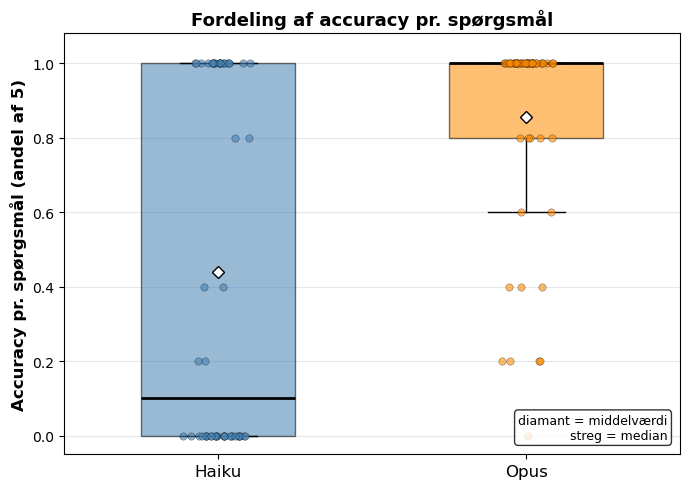

In [16]:
np.random.seed(0)
data = [df["Haiku_acc"], df["Opus_acc"]]; colors = ["steelblue","darkorange"]
fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(data, patch_artist=True, widths=0.5, showmeans=True, showfliers=False,
                meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black"))
for patch, c in zip(bp["boxes"], colors): patch.set_facecolor(c); patch.set_alpha(0.55)
for med in bp["medians"]: med.set_color("black"); med.set_linewidth(2)
for i, (dd, c) in enumerate(zip(data, colors), start=1):
    ax.scatter(np.random.normal(i, 0.045, size=len(dd)), dd, color=c,
               alpha=0.6, edgecolor="black", linewidth=0.3, zorder=3, s=28)
ax.set_xticks([1, 2]); ax.set_xticklabels(["Haiku","Opus"], fontsize=12)
ax.set_ylabel("Accuracy pr. spørgsmål (andel af 5)", fontsize=12, fontweight="bold")
ax.set_title("Fordeling af accuracy pr. spørgsmål", fontsize=13, fontweight="bold")
ax.set_ylim(-0.05, 1.08); ax.grid(True, alpha=0.3, axis="y")
ax.text(0.98, 0.03, "diamant = middelværdi\nstreg = median", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=9, bbox=dict(boxstyle="round", fc="white", alpha=0.8))
plt.tight_layout(); plt.show()

## 11. Selv-konsistens på tværs af de 5 gentagelser
Proxy for hvor "sikker" en model er pr. spørgsmål: $c = \max(k,\,5-k)/5$, hvor $k$ er antal
korrekte. $c=1{,}0$ = samme korrekthed alle 5 gange (decideret); $c=0{,}6$ = 3-2-splittet (vaklende).
**Caveat:** datasættet gemmer kun korrekt/forkert, ikke hvilket svar — $c$ måler konsistens i
korrekthed, ikke i svarvalg. Bemærk: konsistens er ikke korrekthed — en model kan være
konsistent *forkert*.

Unanime spørgsmål (alle 5 ens korrekthed):  Haiku 48/54   Opus 40/54
Gennemsnitlig konsistens:  Haiku 0.970   Opus 0.930


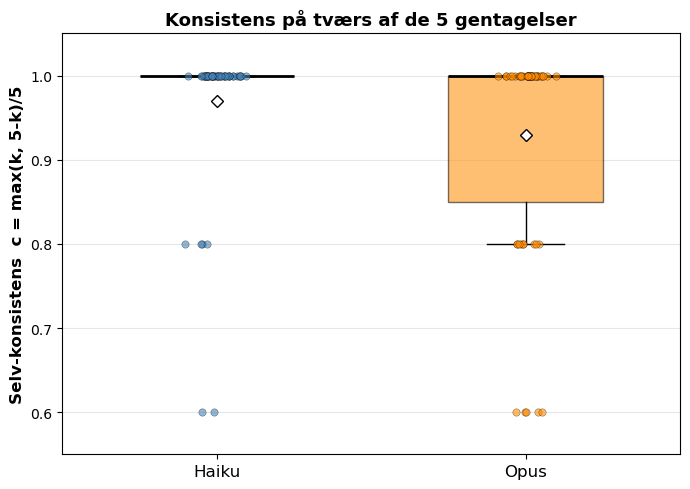

In [17]:
df["Haiku_cons"] = df[["Haiku True", "Haiku False"]].max(axis=1) / REPS
df["Opus_cons"]  = df[["Opus True",  "Opus False"]].max(axis=1) / REPS

uh = int((df["Haiku_cons"] == 1.0).sum()); uo = int((df["Opus_cons"] == 1.0).sum())
print(f"Unanime spørgsmål (alle 5 ens korrekthed):  Haiku {uh}/54   Opus {uo}/54")
print(f"Gennemsnitlig konsistens:  Haiku {df['Haiku_cons'].mean():.3f}   Opus {df['Opus_cons'].mean():.3f}")

np.random.seed(1)
data = [df["Haiku_cons"], df["Opus_cons"]]; colors = ["steelblue","darkorange"]
fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(data, patch_artist=True, widths=0.5, showmeans=True, showfliers=False,
                meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black"))
for patch, c in zip(bp["boxes"], colors): patch.set_facecolor(c); patch.set_alpha(0.55)
for med in bp["medians"]: med.set_color("black"); med.set_linewidth(2)
for i, (dd, c) in enumerate(zip(data, colors), start=1):
    ax.scatter(np.random.normal(i, 0.045, size=len(dd)), dd, color=c,
               alpha=0.6, edgecolor="black", linewidth=0.3, zorder=3, s=28)
ax.set_xticks([1, 2]); ax.set_xticklabels(["Haiku","Opus"], fontsize=12)
ax.set_ylabel("Selv-konsistens  c = max(k, 5-k)/5", fontsize=12, fontweight="bold")
ax.set_title("Konsistens på tværs af de 5 gentagelser", fontsize=13, fontweight="bold")
ax.set_ylim(0.55, 1.05); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## 12. Samlet resultatoversigt + tabel til rapporten

In [18]:
summary = pd.DataFrame({
    "Model": ["Haiku 4.5", "Opus 4.8"],
    "Løst (majority vote)": [f"{m_h}/54", f"{m_o}/54"],
    "Accuracy": [f"{m_h/n:.1%}", f"{m_o/n:.1%}"],
    "Jeffreys 95% CI": [f"[{ci_h[0]:.3f}, {ci_h[1]:.3f}]", f"[{ci_o[0]:.3f}, {ci_o[1]:.3f}]"],
    "Mean accuracy (5 reps)": [f"{df['Haiku_acc'].mean():.1%}", f"{df['Opus_acc'].mean():.1%}"],
    "Unanime spørgsmål": [f"{uh}/54", f"{uo}/54"],
})
print(summary.to_string(index=False))

print()
print("=" * 64)
print(f"McNemar:   theta = {E:+.3f}  CI [{CI_mc[0]:.3f}, {CI_mc[1]:.3f}]  p = {p_mc:.2e}")
print(f"Wilcoxon:  median diff = {np.median(diff):+.3f}  r = {rbc:.3f}  p = {res.pvalue:.2e}")
print("Begge tests: Opus signifikant bedre end Haiku.")
print("=" * 64)

# LaTeX-version af tabellen (kopiér direkte ind i rapporten)
print("\nLaTeX:")
print(summary.to_latex(index=False))

    Model Løst (majority vote) Accuracy Jeffreys 95% CI Mean accuracy (5 reps) Unanime spørgsmål
Haiku 4.5                23/54    42.6%  [0.301, 0.559]                  44.1%             48/54
 Opus 4.8                46/54    85.2%  [0.740, 0.927]                  85.6%             40/54

McNemar:   theta = +0.426  CI [0.271, 0.569]  p = 5.65e-06
Wilcoxon:  median diff = +0.400  r = 0.847  p = 6.40e-06
Begge tests: Opus signifikant bedre end Haiku.

LaTeX:
\begin{tabular}{llllll}
\toprule
Model & Løst (majority vote) & Accuracy & Jeffreys 95% CI & Mean accuracy (5 reps) & Unanime spørgsmål \\
\midrule
Haiku 4.5 & 23/54 & 42.6% & [0.301, 0.559] & 44.1% & 48/54 \\
Opus 4.8 & 46/54 & 85.2% & [0.740, 0.927] & 85.6% & 40/54 \\
\bottomrule
\end{tabular}

